In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
model1 = YOLO("yolo11n-obb.pt")
# 이전에 저장된 가중치 파일(last.pt)을 불러옵니다.
# 주의: 이전 학습이 중단되어 last.pt가 생성된 경우에만 작동합니다.
# model1 = YOLO("runs/detect/train/weights/last.pt")

results = model1.train(
    task='obb',
    data="coco.yaml",
    epochs=200,
    imgsz=640,
    batch=128,
    device=0,)

In [2]:
import os

# Define the source zip file path and target extraction directory
source_zip_path = '/content/drive/MyDrive/model.zip'
target_extract_dir = '/content/model'

# Create the target directory if it doesn't exist
if not os.path.exists(target_extract_dir):
    os.makedirs(target_extract_dir)
    print(f"Created directory: {target_extract_dir}")
else:
    print(f"Directory already exists: {target_extract_dir}")

# Unzip the file to the target directory
# The -q flag makes the unzip command quiet (less verbose output)
# The -d flag specifies the destination directory
!unzip -q "{source_zip_path}" -d "{target_extract_dir}"

print(f"Successfully unzipped '{source_zip_path}' to '{target_extract_dir}'.")
print("You can now list the contents of the directory to verify:")
!ls "{target_extract_dir}"


Created directory: /content/model
replace /content/model/__MACOSX/datasets/._bollard-1? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Successfully unzipped '/content/drive/MyDrive/model.zip' to '/content/model'.
You can now list the contents of the directory to verify:
banner_data_concate.py	 datasets
bollard_data_concate.py  kickboard_data_concate.py
coco_dataset.ipynb	 __MACOSX
coco.yaml		 visualized_test2017_classes.jpg
count_data.py		 visualize_test2017.py


MP_SEL로 시작하는 images, labels 폴더 안의 데이터 삭제.
이거 킥보드라고 해놓고 사실은 점자블록이었음

In [29]:
import os
import glob

base_image_dir = '/content/model/datasets/coco_total/labels'
directories_to_clean = ['test2017', 'train2017', 'val2017']

print("Starting file cleanup...")

for directory in directories_to_clean:
    full_path = os.path.join(base_image_dir, directory)
    if os.path.exists(full_path) and os.path.isdir(full_path):
        print(f"Searching in: {full_path}")
        # Find files starting with 'MP_SEL' (case-sensitive) in the current directory
        # We use os.path.join for robust path construction
        pattern = os.path.join(full_path, 'MP_SEL*')
        files_to_delete = glob.glob(pattern)

        if files_to_delete:
            print(f"Found {len(files_to_delete)} files to delete in {directory}:")
            for file_path in files_to_delete:
                try:
                    os.remove(file_path)
                    print(f"  Deleted: {file_path}")
                except OSError as e:
                    print(f"  Error deleting {file_path}: {e}")
        else:
            print(f"No files starting with 'MP_SEL' found in {directory}.")
    else:
        print(f"Directory not found or is not a directory: {full_path}")

print("File cleanup complete.")

Starting file cleanup...
Searching in: /content/model/datasets/coco_total/labels/test2017
No files starting with 'MP_SEL' found in test2017.
Searching in: /content/model/datasets/coco_total/labels/train2017
No files starting with 'MP_SEL' found in train2017.
Searching in: /content/model/datasets/coco_total/labels/val2017
No files starting with 'MP_SEL' found in val2017.
File cleanup complete.


In [3]:
import os
from collections import Counter
from pathlib import Path

def count_labels():
    base_dir = Path("/content/model/datasets/coco_total")
    labels_dir = base_dir / "labels"

    splits = ["train2017", "val2017", "test2017"]

    total_counts = Counter()

    for split in splits:
        split_dir = labels_dir / split
        split_counts = Counter()

        if not split_dir.exists():
            print(f"Directory not found: {split_dir}")
            continue

        print(f"Processing labels in {split}...")

        # Count labels line by line
        for label_file in os.listdir(split_dir):
            if label_file.endswith(".txt"):
                file_path = split_dir / label_file
                with open(file_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            class_id = int(parts[0])
                            split_counts[class_id] += 1
                            total_counts[class_id] += 1

        print(f"\n--- Counts for {split} ---")
        if not split_counts:
            print("No labels found.")
        else:
            for class_id in sorted(split_counts.keys()):
                print(f"Class {class_id}: {split_counts[class_id]}")

    print("\n===============================")
    print("--- Total Counts across all splits ---")
    if not total_counts:
        print("No labels found across any splits.")
    else:
        for class_id in sorted(total_counts.keys()):
            print(f"Class {class_id}: {total_counts[class_id]}")

if __name__ == "__main__":
    count_labels()


Processing labels in train2017...

--- Counts for train2017 ---
Class 0: 257252
Class 1: 7056
Class 2: 43531
Class 3: 8654
Class 4: 6061
Class 5: 9970
Class 6: 12842
Class 7: 1983
Class 8: 9820
Class 9: 5500
Class 10: 3480
Class 11: 2104
Class 12: 3253
Processing labels in val2017...

--- Counts for val2017 ---
Class 0: 10777
Class 1: 314
Class 2: 1918
Class 3: 367
Class 4: 283
Class 5: 414
Class 6: 634
Class 7: 75
Class 8: 411
Class 9: 218
Class 10: 97
Class 11: 185
Class 12: 111
Processing labels in test2017...

--- Counts for test2017 ---
Class 10: 7
Class 11: 99

--- Total Counts across all splits ---
Class 0: 268029
Class 1: 7370
Class 2: 45449
Class 3: 9021
Class 4: 6344
Class 5: 10384
Class 6: 13476
Class 7: 2058
Class 8: 10231
Class 9: 5718
Class 10: 3584
Class 11: 2388
Class 12: 3364


In [4]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.1 MB/s eta 0:00:00


**Reasoning**:
The ultralytics library has been successfully installed. Now, I will import the YOLO class from ultralytics and define the model architecture and configuration file paths for training.



In [ ]:
# 기존 라이브러리와의 충돌을 방지하기 위해 강제 재설치
!pip uninstall -y torch torchvision torchaudio ultralytics
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install ultralytics

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: ultralytics 8.4.14
Uninstalling ultralytics-8.4.14:
  Successfully uninstalled ultralytics-8.4.14
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 998.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 120.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.1 MB/s eta 0:00:

  Using cached ultralytics-8.4.14-py3-none-any.whl.metadata (39 kB)
Using cached ultralytics-8.4.14-py3-none-any.whl (1.2 MB)


In [8]:
from ultralytics import YOLO

# Define the model
model = YOLO('yolo26n.pt') # Load a pre-trained YOLOv8n model

# Define the paths for the dataset configuration and data directory
data_yaml_path = '/content/model/datasets/coco_total/data.yaml'

print("YOLO model initialized and data configuration path set.")

YOLO model initialized and data configuration path set.


In [9]:
# 조기 종료 옵션이 추가된 학습 코드
results = model.train(
    data=data_yaml_path,
    epochs=1,
    imgsz=640,
    batch=64,
    device=0,
    save=True       # 최적의 모델 가중치 자동 저장
)

print("학습이 완료되었거나 조기 종료 조건에 도달했습니다.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/model/datasets/coco_total/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

In [15]:
# 1. 모델 불러오기 (학습 결과 경로 확인 필요)
# 보통 첫 학습 시 'runs/detect/train/weights/best.pt'에 저장됩니다.
export_model = YOLO('/content/runs/detect/train4/weights/best.pt')

# 2. TFLite 형식으로 내보내기 (Float32가 기본값)
export_model.export(format='tflite')

print("TFLite 변환이 완료되었습니다.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,377,371 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/runs/detect/train4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.20.1 opset 22...
ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 1.9s, saved as '/content/runs/detect/train4/weights/best.onnx' (9.5 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/runs/detect/train4/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 300, 6), dtype=tf.float32, name=None)
Captures:
  137749442189200: TensorSpec(shape

In [32]:
from ultralytics import YOLO

# 이전에 학습된 가중치 로드
model = YOLO('/content/runs/detect/train5/weights/last.pt')

# 새로운 설정으로 학습 시작
model.train(
    data=data_yaml_path,
    epochs=3,      # 더 많이 학습시키고 싶을 때 변경
    imgsz=640,
    batch=32,       # 필요시 변경 가능
    device=0
)

New https://pypi.org/project/ultralytics/8.4.15 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/model/datasets/coco_total/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train5/weights/last.pt, momentum=0.937, mos

KeyboardInterrupt: 

Successfully created zip file: /content/coco_total.zip
You can now find it in the Colab file browser or download it.



image 1/1 /content/100733546.2.jpg: 640x544 2 persons, 11.6ms
Speed: 2.2ms preprocess, 11.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 544)
Results saved to /content/runs/detect/predict9
추론 결과 이미지가 저장되었습니다: runs/detect/predict9/100733546.2.jpg


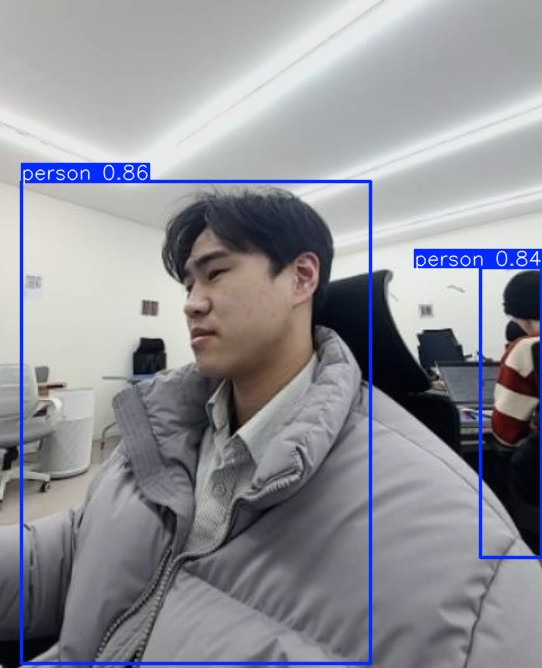

In [25]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# 1. 학습된 모델 로드
model_path = '/content/runs/detect/train5/weights/best.pt'
model = YOLO(model_path)

# 2. 추론할 이미지 경로 설정
image_path = '/content/100733546.2.jpg'

# 3. 모델 추론 실행
# save=True로 설정하면 결과 이미지가 자동으로 'runs/detect/predict' 디렉토리에 저장됩니다.
# confidence threshold를 낮춰서 감지율을 높입니다.
results = model.predict(source=image_path, save=True, conf=0.2)

# 4. 결과 이미지 경로 찾기 및 표시
# 결과는 'runs/detect/predict' 또는 'runs/detect/predictX' 폴더에 저장됩니다.
# 가장 최근에 생성된 predict 폴더를 찾아 그 안에 있는 이미지 파일을 가져옵니다.
predict_dir = sorted([d for d in os.listdir('runs/detect') if d.startswith('predict')])[-1]
result_image_path = os.path.join('runs/detect', predict_dir, os.path.basename(image_path))

if os.path.exists(result_image_path):
    print(f"추론 결과 이미지가 저장되었습니다: {result_image_path}")
    display(Image(filename=result_image_path))
else:
    print("결과 이미지를 찾을 수 없습니다. 경로를 확인해주세요.")
    print(f"생성된 예측 디렉토리: {os.path.join('runs/detect', predict_dir)}")
    !ls -R {os.path.join('runs/detect', predict_dir)}

In [20]:
import yaml

# data_yaml_path 변수는 이미 노트북에 정의되어 있습니다.
# data_yaml_path = '/content/model/datasets/coco_total/data.yaml'

# YAML 파일 읽기
with open(data_yaml_path, 'r', encoding='utf-8') as f:
    data_config = yaml.safe_load(f)

# 클래스 이름 (names) 출력
if 'names' in data_config:
    print("Model Labels (Class Names):")
    for i, name in enumerate(data_config['names']):
        print(f"Class {i}: {name}")
else:
    print("data.yaml 파일에서 'names' 키를 찾을 수 없습니다.")

print("\nFull data.yaml content:")
print(yaml.dump(data_config, default_flow_style=False))

Model Labels (Class Names):
Class 0: 0
Class 1: 1
Class 2: 2
Class 3: 3
Class 4: 4
Class 5: 5
Class 6: 6
Class 7: 7
Class 8: 8
Class 9: 9
Class 10: 10
Class 11: 11
Class 12: 12

Full data.yaml content:
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: bus
  5: truck
  6: traffic light
  7: stop sign
  8: bench
  9: dog
  10: bollard
  11: banner
  12: kickboard
path: /content/model/datasets/coco_total
train: images/train2017
val: images/val2017



In [26]:
from ultralytics import YOLO

# 이전에 학습된 가중치 로드
model = YOLO('/content/runs/detect/train5/weights/last.pt')

# 새로운 설정으로 학습 시작
model.train(
    data=data_yaml_path,
    epochs=1,      # 더 많이 학습시키고 싶을 때 변경
    imgsz=640,
    batch=32,       # 필요시 변경 가능
    device=0
)

New https://pypi.org/project/ultralytics/8.4.15 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/model/datasets/coco_total/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train4/weights/last.pt, momentum=0.937, mos

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d48503c6600>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [14]:
from ultralytics import YOLO

# 1. 학습된 모델 로드 (경로는 본인의 환경에 맞춰 수정)
model = YOLO('/content/runs/detect/train4/weights/best.pt')

# 2. 검증(Validation) 실행
metrics = model.val(data='/content/model/datasets/coco_total/data.yaml')

# 3. 주요 지표 출력
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,377,371 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2571.7±376.8 MB/s, size: 185.9 KB)
val: Scanning /content/model/datasets/coco_total/labels/val2017.cache... 3414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3414/3414 1.1Git/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 15542, len(boxes) = 15804. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 214/214 8.3it/s 25.9s
                   all       3414      15804      0.547      0.427      0.449      0.312
                person       2693      10777      0.689      0.603      0.667      0.443
           

In [ ]:
from google.colab import files
import os

# 1. TFLite 파일이 저장된 예상 경로 설정
# (일반적으로 학습 결과 가중치 폴더 안에 생성됩니다)
tflite_path = '/content/runs/detect/train/weights/best_float32.tflite'

# 2. 파일 존재 여부 확인 후 다운로드 실행
if os.path.exists(tflite_path):
    files.download(tflite_path)
    print(f"{tflite_path} 다운로드를 시작합니다.")
else:
    # 파일 이름이 다를 경우 폴더 내의 .tflite 파일을 직접 찾아 출력
    print("지정한 경로에 파일이 없습니다. 폴더 내 파일 목록을 확인하세요:")
    !ls -R /content/runs/detect/train/weights/

In [ ]:
import shutil
import os

# 1. 원본 파일 경로 (코랩 로컬)
source_path = '/content/runs/detect/train/weights/best_float32.tflite'

# 2. 구글 드라이브 내 저장 폴더 생성 및 경로 설정
drive_folder = '/content/drive/MyDrive/YOLO_Export'
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

# 3. 파일 존재 여부 확인 후 복사 실행
if os.path.exists(source_path):
    dest_path = os.path.join(drive_folder, 'best_float32.tflite')
    shutil.copy(source_path, dest_path)
    print(f"파일이 구글 드라이브로 복사되었습니다: {dest_path}")
else:
    print("원본 경로에 .tflite 파일이 없습니다. 경로를 확인해주세요.")
    # 실제 생성된 파일명을 확인하기 위한 명령어
    !ls -R /content/runs/detect/train/weights/

In [35]:
import os

source_dir = '/content/model/datasets/coco_total'
output_zip = '/content/coco_total.zip'

# -r: recurse into directories
# -q: quiet operation (do not print names on screen)
# -j: junk path (store just the name of a saved file, not its path components)
# If you want to include the directory structure, remove -j.
# For this case, we want to zip the content of the directory, not just the directory name itself, so we will omit -j.

# Navigate to the parent directory of source_dir and zip its content
# This ensures the zip file contains 'coco_total/...' rather than '/content/model/datasets/coco_total/...' inside the zip
current_dir = os.getcwd()
os.chdir(os.path.dirname(source_dir))

# Get the base name of the directory to be zipped
base_name_to_zip = os.path.basename(source_dir)

# Execute the zip command
!zip -r -q "{output_zip}" "{base_name_to_zip}"

# Change back to the original directory
os.chdir(current_dir)

if os.path.exists(output_zip):
    print(f"Successfully created zip file: {output_zip}")
    print("You can now find it in the Colab file browser or download it.")
else:
    print(f"Failed to create zip file at {output_zip}")



zip error: Interrupted (aborting)
Failed to create zip file at /content/coco_total.zip


In [36]:
import shutil
import os

source_path = '/content/coco_total.zip'
destination_path = '/content/drive/MyDrive/coco_total.zip'

# Check if the source file exists
if os.path.exists(source_path):
    try:
        # Move the file
        shutil.move(source_path, destination_path)
        print(f"File '{source_path}' successfully moved to '{destination_path}'.")
    except Exception as e:
        print(f"Error moving file: {e}")
else:
    print(f"Source file '{source_path}' does not exist. Please check the path.")

# Optionally, verify the file is in the new location
if os.path.exists(destination_path):
    print("Verification: File found in Google Drive.")
else:
    print("Verification: File not found in Google Drive.")

Source file '/content/coco_total.zip' does not exist. Please check the path.
Verification: File found in Google Drive.
